In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('concated_2_vectors.csv')

In [3]:
df.target_x.value_counts()

0.0    4395
1.0    1005
Name: target_x, dtype: int64

In [4]:
df.target_y.value_counts()

0.0    5302
1.0      98
Name: target_y, dtype: int64

In [5]:
df_train,df_val,df_test=df[df["dataset"]=="train"],df[df["dataset"]=="val"],df[df["dataset"]=="test"]
df_train


,Stkcd,target_x,year_1,year_2,embedding_0_x,embedding_1_x,embedding_2_x,embedding_3_x,embedding_4_x,embedding_5_x,...,embedding_119_y,embedding_120_y,embedding_121_y,embedding_122_y,embedding_123_y,embedding_124_y,embedding_125_y,embedding_126_y,embedding_127_y,dataset
0,2,0.0,2010,2011,0.964028,0.0,0.964028,0.0,0.0,0.0,...,1.154781e-30,8.260624e-17,-0.0,0.0,-2.494888e-35,0.761594,-0.761594,-0.761594,0.0,train
1,2,0.0,2011,2012,0.964028,0.0,0.964028,0.0,0.0,0.0,...,7.923801e-31,4.954916e-17,-0.0,0.0,-2.935651e-35,0.761594,-0.761594,-0.761594,0.0,train
2,2,0.0,2012,2013,0.964028,0.0,0.964028,0.0,0.0,0.0,...,6.245424e-31,5.684070e-17,-0.0,0.0,-4.089037e-35,0.761594,-0.761594,-0.761594,0.0,train
3,2,0.0,2013,2014,0.964028,0.0,0.964028,0.0,0.0,0.0,...,6.402951e-31,6.326300e-17,-0.0,0.0,-6.991075e-35,0.761594,-0.761594,-0.761594,0.0,train
4,2,0.0,2014,2015,0.964028,0.0,0.964028,0.0,0.0,0.0,...,4.555814e-31,4.314276e-17,-0.0,0.0,-5.214611e-35,0.761594,-0.761594,-0.761594,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,601919,1.0,2012,2013,0.964028,0.0,0.964028,0.0,0.0,0.0,...,7.485180e-31,4.353923e-17,-0.0,0.0,-3.745093e-35,0.761594,-0.761594,-0.761594,0.0,train
3146,601919,1.0,2013,2014,0.964028,0.0,0.964028,0.0,0.0,0.0,...,6.848171e-31,3.847692e-17,-0.0,0.0,-5.231215e-35,0.761594,-0.761594,-0.761594,0.0,train
3147,601919,1.0,2014,2015,0.964028,0.0,0.964028,0.0,0.0,0.0,...,4.595085e-31,3.450233e-17,-0.0,0.0,-6.046622e-35,0.761594,-0.761594,-0.761594,0.0,train
3148,601919,1.0,2015,2016,0.964028,0.0,0.964028,0.0,0.0,0.0,...,3.846198e-31,2.727558e-17,-0.0,0.0,-7.097789e-35,0.761594,-0.761594,-0.761594,0.0,train


In [6]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 准备数据
feature_columns = [col for col in df_train.columns if col not in ['target_x', 'target_y','dataset','Stkcd','year_1','year_2']]
X = df_train[feature_columns].values
y_x = df_train['target_x'].values
y_y = df_train['target_y'].values

# 打印重采样前的分布
print("重采样前的分布：")
print("Target X分布:", Counter(y_x))
print("Target Y分布:", Counter(y_y))

# 创建一个复合标签，将两个目标组合成一个
y_combined = np.array([(x, y) for x, y in zip(y_x, y_y)])
unique_labels = np.unique(y_combined, axis=0)
print("\n独特的标签组合：")
for label in unique_labels:
    count = sum((y_combined == label).all(axis=1))
    print(f"(X={label[0]}, Y={label[1]}): {count}个样本")

# 对复合标签进行SMOTE过采样
smote = SMOTE(random_state=42)
# 将复合标签转换为单一标签以用于SMOTE
label_to_int = {tuple(label): i for i, label in enumerate(unique_labels)}
y_encoded = np.array([label_to_int[tuple(label)] for label in y_combined])

# 进行过采样
X_resampled, y_encoded_resampled = smote.fit_resample(X, y_encoded)

# 将编码后的标签转回原始格式
int_to_label = {i: label for label, i in label_to_int.items()}
y_resampled = np.array([int_to_label[i] for i in y_encoded_resampled])

# 分离回两个目标
y_x_final = y_resampled[:, 0]
y_y_final = y_resampled[:, 1]
X_final = X_resampled

print("\n重采样后的分布：")
print("数据集大小：", X_final.shape)
print("Target X分布:", Counter(y_x_final))
print("Target Y分布:", Counter(y_y_final))

# 转换为PyTorch张量
X_tensor = torch.FloatTensor(X_final)
y_x_tensor = torch.FloatTensor(y_x_final)
y_y_tensor = torch.FloatTensor(y_y_final)

# 模型参数
input_dim = X_final.shape[1]  # 输入维度（拼接后的BiLSTM隐藏层向量维度）
hidden_dim = 128       # 隐藏层维度
output_dim = 1         # 输出维度（二分类）




重采样前的分布：
Target X分布: Counter({0.0: 2604, 1.0: 546})
Target Y分布: Counter({0.0: 3111, 1.0: 39})

独特的标签组合：
(X=0.0, Y=0.0): 2578个样本
(X=0.0, Y=1.0): 26个样本
(X=1.0, Y=0.0): 533个样本
(X=1.0, Y=1.0): 13个样本

重采样后的分布：
数据集大小： (10312, 256)
Target X分布: Counter({0.0: 5156, 1.0: 5156})
Target Y分布: Counter({0.0: 5156, 1.0: 5156})


d:\Anaconda\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [12]:
2240/14

160.0

In [7]:
class FusionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FusionModel, self).__init__()
        
        # 特征提取层
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # 任务特定的特征处理层 - 财务困境
        self.financial_specific = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # 任务特定的特征处理层 - 内部控制
        self.internal_specific = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # 输出层
        self.classifier_financial = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )
        
        self.classifier_internal = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        # 共享特征提取
        shared_features = self.feature_extractor(x)
        
        # 任务特定特征处理
        financial_features = self.financial_specific(shared_features)
        internal_features = self.internal_specific(shared_features)
        
        # 预测
        pred_financial = self.classifier_financial(financial_features)
        pred_internal = self.classifier_internal(internal_features)
        
        return pred_financial, pred_internal


In [8]:
# 初始化模型
model = FusionModel(input_dim, hidden_dim)  # 移除output_dim参数，因为输出维度固定为1（二分类）

# 定义损失函数和优化器
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# 定义损失函数（带权重的BCE损失）
class WeightedBCELoss(nn.Module):
    def __init__(self, weights):
        super(WeightedBCELoss, self).__init__()
        self.weights = weights
        
    def forward(self, pred, target):
        bce = -(target * torch.log(pred + 1e-10) + (1 - target) * torch.log(1 - pred + 1e-10))
        weighted_bce = self.weights[1] * target * bce + self.weights[0] * (1 - target) * bce
        return weighted_bce.mean()

# 计算类别权重
pos_weight_x = (y_x_tensor == 0).sum().float() / (y_x_tensor == 1).sum().float()
pos_weight_y = (y_y_tensor == 0).sum().float() / (y_y_tensor == 1).sum().float()

criterion_financial = WeightedBCELoss(weights=torch.tensor([1.0, pos_weight_x]))
criterion_internal = WeightedBCELoss(weights=torch.tensor([1.0, pos_weight_y]))

# 使用带有权重衰减的AdamW优化器和学习率调度器
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

d:\Anaconda\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [9]:
# 训练模型
num_epochs = 20
batch_size = 32

# 用于记录损失
losses_x = []
losses_y = []
total_losses = []

for epoch in range(num_epochs):
    model.train()
    
    # 前向传播
    pred_x, pred_y = model(X_tensor)
    
    # 计算损失
    loss_x = criterion(pred_x.squeeze(), y_x_tensor)
    loss_y = criterion(pred_y.squeeze(), y_y_tensor)
    total_loss = loss_x + loss_y
    
    # 记录损失
    losses_x.append(loss_x.item())
    losses_y.append(loss_y.item())
    total_losses.append(total_loss.item())
    
    # 反向传播和优化
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Loss X (FD风险): {loss_x.item():.4f}')
        print(f'Loss Y (IC风险): {loss_y.item():.4f}')
        print(f'Total Loss: {total_loss.item():.4f}')
        print('-' * 50)

Epoch [10/20]
Loss X (FD风险): 0.6692
Loss Y (IC风险): 0.5827
Total Loss: 1.2518
--------------------------------------------------
Epoch [20/20]
Loss X (FD风险): 0.6540
Loss Y (IC风险): 0.4853
Total Loss: 1.1393
--------------------------------------------------


In [13]:
class FusionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FusionModel, self).__init__()
        
        # 简化的特征提取层
        self.shared_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # 财务困境任务分支
        self.financial_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        # 内部控制任务分支
        self.internal_branch = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x):
        # 共享特征
        shared_features = self.shared_layer(x)
        
        # 任务特定预测
        financial_logits = self.financial_branch(shared_features)
        internal_logits = self.internal_branch(shared_features)
        
        # 使用logits而不是直接使用sigmoid
        return financial_logits, internal_logits

# 重新定义损失函数和训练过程
def train_model(model, train_loader, num_epochs=150):
    # 使用BCEWithLogitsLoss，它会在内部处理sigmoid
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    
    # 计算类别权重
    financial_pos_weight = torch.tensor([(y_x_tensor == 0).sum() / (y_x_tensor == 1).sum()])
    internal_pos_weight = torch.tensor([(y_y_tensor == 0).sum() / (y_y_tensor == 1).sum()])
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.01)
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for batch_X, batch_y_x, batch_y_y in train_loader:
            optimizer.zero_grad()
            
            # 前向传播
            financial_logits, internal_logits = model(batch_X)
            
            # 计算加权损失
            financial_loss = criterion(financial_logits, batch_y_x.view(-1, 1))
            internal_loss = criterion(internal_logits, batch_y_y.view(-1, 1))
            
            # 应用类别权重
            financial_loss = (financial_loss * (batch_y_x.view(-1, 1) * (financial_pos_weight - 1) + 1)).mean()
            internal_loss = (internal_loss * (batch_y_y.view(-1, 1) * (internal_pos_weight - 1) + 1)).mean()
            
            # 总损失
            loss = financial_loss + internal_loss
            
            # 反向传播
            loss.backward()
            
            # 梯度裁剪
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}')

# 创建新的数据加载器
batch_size = 64  # 增大批次大小
dataset = TensorDataset(X_tensor, y_x_tensor, y_y_tensor)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 初始化新模型
model = FusionModel(input_dim=X_tensor.shape[1], hidden_dim=64)  # 减小隐藏层维度

# 训练模型
train_model(model, train_loader)


Epoch [10/150], Loss: 1.3867
Epoch [20/150], Loss: 1.3863
Epoch [30/150], Loss: 1.3865
Epoch [40/150], Loss: 1.3864
Epoch [50/150], Loss: 1.3864
Epoch [60/150], Loss: 1.3863
Epoch [70/150], Loss: 1.3863
Epoch [80/150], Loss: 1.3863
Epoch [90/150], Loss: 1.3863
Epoch [100/150], Loss: 1.3863
Epoch [110/150], Loss: 1.3863
Epoch [120/150], Loss: 1.3863
Epoch [130/150], Loss: 1.3863
Epoch [140/150], Loss: 1.3863
Epoch [150/150], Loss: 1.3863


财务困境风险预测结果：

不同阈值的效果：

阈值 = 0.3
              precision    recall  f1-score   support

          正常       0.00      0.00      0.00      1791
          困境       0.20      1.00      0.34       459

    accuracy                           0.20      2250
   macro avg       0.10      0.50      0.17      2250
weighted avg       0.04      0.20      0.07      2250


阈值 = 0.4
              precision    recall  f1-score   support

          正常       0.00      0.00      0.00      1791
          困境       0.20      1.00      0.34       459

    accuracy                           0.20      2250
   macro avg       0.10      0.50      0.17      2250
weighted avg       0.04      0.20      0.07      2250


阈值 = 0.5
              precision    recall  f1-score   support

          正常       0.80      1.00      0.89      1791
          困境       0.00      0.00      0.00       459

    accuracy                           0.80      2250
   macro avg       0.40      0.50      0.44      2250
weighted avg       0.6

d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: Undefine

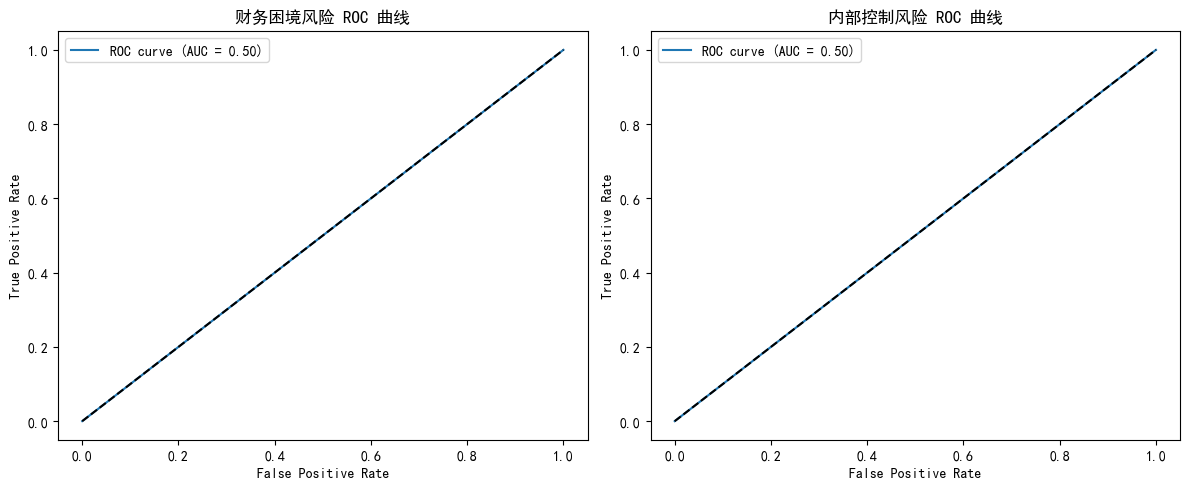

In [14]:
# 准备测试数据
test_feature_columns = [col for col in df_test.columns if col not in ['target_x', 'target_y', 'dataset', 'Stkcd', 'year_1', 'year_2']]
X_test = df_test[test_feature_columns].values
y_test_x = df_test['target_x'].values
y_test_y = df_test['target_y'].values

# 转换为PyTorch张量
X_test_tensor = torch.FloatTensor(X_test)
y_test_x_tensor = torch.FloatTensor(y_test_x)
y_test_y_tensor = torch.FloatTensor(y_test_y)

# 评估函数
def evaluate_model(model, X, y_true_x, y_true_y, threshold=0.5):
    model.eval()
    with torch.no_grad():
        # 获取预测
        financial_logits, internal_logits = model(X)
        
        # 转换为概率
        pred_x_prob = torch.sigmoid(financial_logits).squeeze().numpy()
        pred_y_prob = torch.sigmoid(internal_logits).squeeze().numpy()
        
        # 使用不同的阈值
        thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
        
        print("财务困境风险预测结果：")
        print("\n不同阈值的效果：")
        for thresh in thresholds:
            pred_x = (pred_x_prob > thresh).astype(int)
            print(f"\n阈值 = {thresh}")
            print(classification_report(y_true_x, pred_x, target_names=['正常', '困境']))
        
        print("\n内部控制风险预测结果：")
        print("\n不同阈值的效果：")
        for thresh in thresholds:
            pred_y = (pred_y_prob > thresh).astype(int)
            print(f"\n阈值 = {thresh}")
            print(classification_report(y_true_y, pred_y, target_names=['正常', '风险']))
        
        # 绘制ROC曲线
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        fpr_x, tpr_x, _ = roc_curve(y_true_x, pred_x_prob)
        roc_auc_x = auc(fpr_x, tpr_x)
        plt.plot(fpr_x, tpr_x, label=f'ROC curve (AUC = {roc_auc_x:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('财务困境风险 ROC 曲线')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        fpr_y, tpr_y, _ = roc_curve(y_true_y, pred_y_prob)
        roc_auc_y = auc(fpr_y, tpr_y)
        plt.plot(fpr_y, tpr_y, label=f'ROC curve (AUC = {roc_auc_y:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('内部控制风险 ROC 曲线')
        plt.legend()
        
        plt.tight_layout()
        plt.show()

# 评估模型
from sklearn.metrics import roc_curve, auc
evaluate_model(model, X_test_tensor, y_test_x, y_test_y)


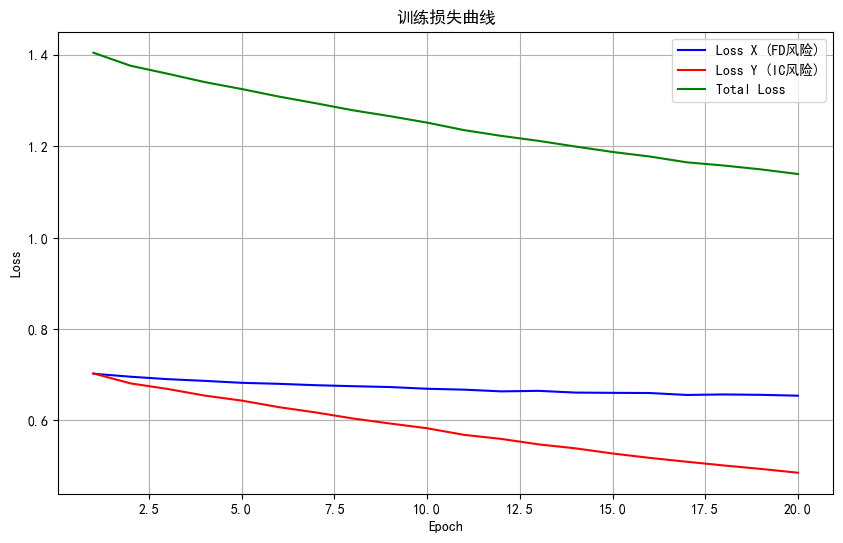

In [10]:
# 绘制损失曲线
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"] # 设置字体为黑体
plt.rcParams["axes.unicode_minus"] = False # 正常显示负号

plt.figure(figsize=(10, 6))
epochs = range(1, num_epochs + 1)
plt.plot(epochs, losses_x, 'b-', label='Loss X (FD风险)')
plt.plot(epochs, losses_y, 'r-', label='Loss Y (IC风险)')
plt.plot(epochs, total_losses, 'g-', label='Total Loss')
plt.title('训练损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


财务困境风险预测报告：
              precision    recall  f1-score   support

          正常       0.00      0.00      0.00      1791
          困境       0.20      1.00      0.34       459

    accuracy                           0.20      2250
   macro avg       0.10      0.50      0.17      2250
weighted avg       0.04      0.20      0.07      2250


内部控制风险预测报告：
              precision    recall  f1-score   support

          正常       1.00      0.00      0.00      2191
          风险       0.03      1.00      0.05        59

    accuracy                           0.03      2250
   macro avg       0.51      0.50      0.03      2250
weighted avg       0.97      0.03      0.00      2250



d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


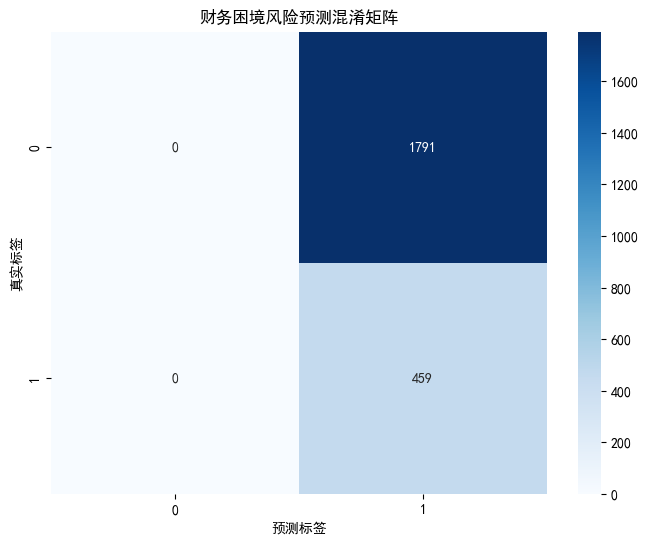

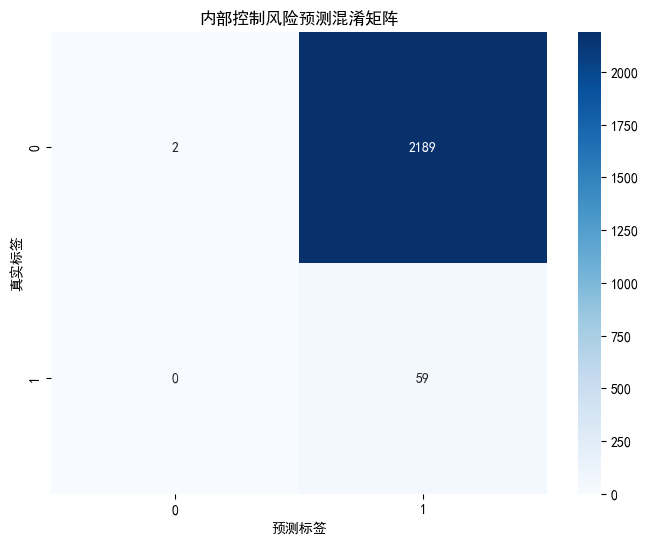


财务困境风险预测概率统计：
整体概率分布：
平均值：0.5418
标准差：0.0015
最小值：0.5038
最大值：0.5551

按真实标签分组的概率分布：
标签 0:
样本数量：1791
平均预测概率：0.5417
预测概率标准差：0.0015
最小预测概率：0.5038
最大预测概率：0.5551

标签 1:
样本数量：459
平均预测概率：0.5419
预测概率标准差：0.0014
最小预测概率：0.5374
最大预测概率：0.5510


内部控制风险预测概率统计：
整体概率分布：
平均值：0.5615
标准差：0.0067
最小值：0.4839
最大值：0.6124

按真实标签分组的概率分布：
标签 0:
样本数量：2191
平均预测概率：0.5613
预测概率标准差：0.0060
最小预测概率：0.4839
最大预测概率：0.6124

标签 1:
样本数量：59
平均预测概率：0.5685
预测概率标准差：0.0171
最小预测概率：0.5131
最大预测概率：0.6115



In [11]:

df_test = pd.concat([df_test, df_val], ignore_index=True) 
# 准备测试集数据
test_feature_columns = [col for col in df_test.columns if col not in ['target_x', 'target_y', 'dataset', 'Stkcd', 'year_1', 'year_2']]
X_test = df_test[test_feature_columns].values
y_test_x = df_test['target_x'].values
y_test_y = df_test['target_y'].values

# 转换为PyTorch张量
X_test_tensor = torch.FloatTensor(X_test)
y_test_x_tensor = torch.FloatTensor(y_test_x)
y_test_y_tensor = torch.FloatTensor(y_test_y)

# 设置模型为评估模式
model.eval()

# 使用模型进行预测
with torch.no_grad():
    pred_x, pred_y = model(X_test_tensor)
    pred_x = pred_x.squeeze().numpy()
    pred_y = pred_y.squeeze().numpy()
    
    # 将概率转换为类别标签（使用0.5作为阈值）
    pred_x_labels = (pred_x > 0.5).astype(int)
    pred_y_labels = (pred_y > 0.5).astype(int)

# 导入必要的库
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 打印分类报告
print("财务困境风险预测报告：")
print(classification_report(y_test_x, pred_x_labels, target_names=['正常', '困境']))
print("\n内部控制风险预测报告：")
print(classification_report(y_test_y, pred_y_labels, target_names=['正常', '风险']))

# 创建混淆矩阵可视化函数
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('真实标签')
    plt.xlabel('预测标签')
    plt.show()

# 绘制混淆矩阵
plot_confusion_matrix(y_test_x, pred_x_labels, '财务困境风险预测混淆矩阵')
plot_confusion_matrix(y_test_y, pred_y_labels, '内部控制风险预测混淆矩阵')

# 计算并打印每个类别的具体预测概率分布
def print_probability_stats(probs, y_true, risk_type):
    print(f"\n{risk_type}预测概率统计：")
    print(f"整体概率分布：")
    print(f"平均值：{probs.mean():.4f}")
    print(f"标准差：{probs.std():.4f}")
    print(f"最小值：{probs.min():.4f}")
    print(f"最大值：{probs.max():.4f}")
    
    print(f"\n按真实标签分组的概率分布：")
    for label in [0, 1]:
        mask = y_true == label
        if mask.any():
            print(f"标签 {label}:")
            print(f"样本数量：{mask.sum()}")
            print(f"平均预测概率：{probs[mask].mean():.4f}")
            print(f"预测概率标准差：{probs[mask].std():.4f}")
            print(f"最小预测概率：{probs[mask].min():.4f}")
            print(f"最大预测概率：{probs[mask].max():.4f}")
            print()

# 打印预测概率统计信息
print_probability_stats(pred_x, y_test_x, "财务困境风险")
print_probability_stats(pred_y, y_test_y, "内部控制风险")

In [8]:
# 检查原始数据分布
print("原始数据中各类别的分布：")
print("\nTarget X (金融风险):")
print(df['target_x'].value_counts())
print("\nTarget Y (运营风险):")
print(df['target_y'].value_counts())
print("\nTarget Z (第三类风险):")
print(df['target'].value_counts())

print("\n训练集中各类别的分布：")
print("\nTarget X (金融风险):")
print(df_train['target_x'].value_counts())
print("\nTarget Y (运营风险):")
print(df_train['target_y'].value_counts())
print("\nTarget Z (第三类风险):")
print(df_train['target'].value_counts())

print("\n测试集中各类别的分布：")
print("\nTarget X (金融风险):")
print(df_test['target_x'].value_counts())
print("\nTarget Y (运营风险):")
print(df_test['target_y'].value_counts())
print("\nTarget Z (第三类风险):")
print(df_test['target'].value_counts())


原始数据中各类别的分布：

Target X (金融风险):
0.0    226
1.0    202
Name: target_x, dtype: int64

Target Y (运营风险):
2.0    222
1.0    177
0.0     29
Name: target_y, dtype: int64

Target Z (第三类风险):
0.0    423
1.0      5
Name: target, dtype: int64

训练集中各类别的分布：

Target X (金融风险):
0.0    169
1.0    152
Name: target_x, dtype: int64

Target Y (运营风险):
2.0    166
1.0    134
0.0     21
Name: target_y, dtype: int64

Target Z (第三类风险):
0.0    318
1.0      3
Name: target, dtype: int64

测试集中各类别的分布：

Target X (金融风险):
0.0    57
1.0    50
Name: target_x, dtype: int64

Target Y (运营风险):
2.0    56
1.0    43
0.0     8
Name: target_y, dtype: int64

Target Z (第三类风险):
0.0    105
1.0      2
Name: target, dtype: int64


In [15]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# 准备数据
feature_columns = [col for col in df_train.columns if col not in ['target_x', 'target_y', 'target', 'dataset', 'Stkcd', 'target_year', 'year_1', 'year_2']]
X = df_train[feature_columns].values
y_x = df_train['target_x'].values
y_y = df_train['target_y'].values  # 三分类
y_z = df_train['target'].values

# 打印重采样前的分布
print("重采样前的分布：")
print("Target X分布 (金融风险):", Counter(y_x))
print("Target Y分布 (运营风险):", Counter(y_y))
print("Target Z分布 (第三类风险):", Counter(y_z))

# 创建一个复合标签，将三个目标组合成一个
y_combined = np.array([(x, y, z) for x, y, z in zip(y_x, y_y, y_z)])
unique_labels = np.unique(y_combined, axis=0)
print("\n独特的标签组合：")
for label in unique_labels:
    count = sum((y_combined == label).all(axis=1))
    print(f"(X={label[0]}, Y={label[1]}, Z={label[2]}): {count}个样本")

# 对复合标签进行SMOTE过采样
smote = SMOTE(random_state=42,k_neighbors=1)
# 将复合标签转换为单一标签以用于SMOTE
label_to_int = {tuple(label): i for i, label in enumerate(unique_labels)}
y_encoded = np.array([label_to_int[tuple(label)] for label in y_combined])

# 进行过采样
X_resampled, y_encoded_resampled = smote.fit_resample(X, y_encoded)

# 将编码后的标签转回原始格式
int_to_label = {i: label for label, i in label_to_int.items()}
y_resampled = np.array([int_to_label[i] for i in y_encoded_resampled])

# 分离回三个目标
y_x_final = y_resampled[:, 0]
y_y_final = y_resampled[:, 1]
y_z_final = y_resampled[:, 2]
X_final = X_resampled

print("\n重采样后的分布：")
print("数据集大小：", X_final.shape)
print("Target X分布 (金融风险):", Counter(y_x_final))
print("Target Y分布 (运营风险):", Counter(y_y_final))
print("Target Z分布 (第三类风险):", Counter(y_z_final))


重采样前的分布：
Target X分布 (金融风险): Counter({0.0: 169, 1.0: 152})
Target Y分布 (运营风险): Counter({2.0: 166, 1.0: 134, 0.0: 21})
Target Z分布 (第三类风险): Counter({0.0: 318, 1.0: 3})

独特的标签组合：
(X=0.0, Y=0.0, Z=0.0): 11个样本
(X=0.0, Y=1.0, Z=0.0): 95个样本
(X=0.0, Y=2.0, Z=0.0): 63个样本
(X=1.0, Y=0.0, Z=0.0): 7个样本
(X=1.0, Y=0.0, Z=1.0): 3个样本
(X=1.0, Y=1.0, Z=0.0): 39个样本
(X=1.0, Y=2.0, Z=0.0): 103个样本

重采样后的分布：
数据集大小： (721, 384)
Target X分布 (金融风险): Counter({1.0: 412, 0.0: 309})
Target Y分布 (运营风险): Counter({0.0: 309, 2.0: 206, 1.0: 206})
Target Z分布 (第三类风险): Counter({0.0: 618, 1.0: 103})


d:\Anaconda\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [18]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# 定义融合模型
class FusionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FusionModel, self).__init__()
        
        # 全连接融合层
        self.fusion = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # 分类输出层
        self.classifier_x = nn.Linear(hidden_dim // 2, 1)     # 金融风险（二分类）
        self.classifier_y = nn.Linear(hidden_dim // 2, 3)     # 运营风险（三分类）
        self.classifier_z = nn.Linear(hidden_dim // 2, 1)     # 第三个风险（二分类）
        
    def forward(self, x):
        # 特征融合
        fused_features = self.fusion(x)
        
        # 分类预测
        pred_x = torch.sigmoid(self.classifier_x(fused_features))      # 金融风险预测（二分类）
        pred_y = torch.softmax(self.classifier_y(fused_features), dim=1)  # 运营风险预测（三分类）
        pred_z = torch.sigmoid(self.classifier_z(fused_features))      # 第三个风险预测（二分类）
        
        return pred_x, pred_y, pred_z

In [19]:
# 转换为PyTorch张量
X_tensor = torch.FloatTensor(X_resampled)
y_x_tensor = torch.FloatTensor(y_x_final)
y_y_tensor = torch.LongTensor(y_y_final)  # 使用LongTensor因为是分类标签
y_z_tensor = torch.FloatTensor(y_z_final)

# 模型参数
input_dim = X_final.shape[1]  # 输入维度
hidden_dim = 128             # 隐藏层维度

# 初始化模型
model = FusionModel(input_dim, hidden_dim)

# 定义损失函数
criterion_binary = nn.BCELoss()  # 二分类问题的损失函数
criterion_multi = nn.CrossEntropyLoss()  # 多分类问题的损失函数

# 定义优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练模型
num_epochs = 200
batch_size = 32

# 用于记录损失
losses_x = []
losses_y = []
losses_z = []
total_losses = []

for epoch in range(num_epochs):
    model.train()
    
    # 前向传播
    pred_x, pred_y, pred_z = model(X_tensor)
    
    # 计算损失
    loss_x = criterion_binary(pred_x.squeeze(), y_x_tensor)  # 二分类损失
    loss_y = criterion_multi(pred_y, y_y_tensor)  # 三分类损失
    loss_z = criterion_binary(pred_z.squeeze(), y_z_tensor)  # 二分类损失
    
    total_loss = loss_x + loss_y + loss_z
    
    # 记录损失
    losses_x.append(loss_x.item())
    losses_y.append(loss_y.item())
    losses_z.append(loss_z.item())
    total_losses.append(total_loss.item())
    
    # 反向传播和优化
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Loss X (金融风险): {loss_x.item():.4f}')
        print(f'Loss Y (运营风险): {loss_y.item():.4f}')
        print(f'Loss Z (第三类风险): {loss_z.item():.4f}')
        print(f'Total Loss: {total_loss.item():.4f}')
        print('-' * 50)


Epoch [10/200]
Loss X (金融风险): 0.6851
Loss Y (运营风险): 1.0977
Loss Z (第三类风险): 0.5335
Total Loss: 2.3163
--------------------------------------------------
Epoch [20/200]
Loss X (金融风险): 0.6920
Loss Y (运营风险): 1.0851
Loss Z (第三类风险): 0.4146
Total Loss: 2.1917
--------------------------------------------------
Epoch [30/200]
Loss X (金融风险): 0.6869
Loss Y (运营风险): 1.0797
Loss Z (第三类风险): 0.4210
Total Loss: 2.1876
--------------------------------------------------
Epoch [40/200]
Loss X (金融风险): 0.6822
Loss Y (运营风险): 1.0816
Loss Z (第三类风险): 0.4170
Total Loss: 2.1809
--------------------------------------------------
Epoch [50/200]
Loss X (金融风险): 0.6869
Loss Y (运营风险): 1.0788
Loss Z (第三类风险): 0.4176
Total Loss: 2.1834
--------------------------------------------------
Epoch [60/200]
Loss X (金融风险): 0.6848
Loss Y (运营风险): 1.0858
Loss Z (第三类风险): 0.4061
Total Loss: 2.1766
--------------------------------------------------
Epoch [70/200]
Loss X (金融风险): 0.6866
Loss Y (运营风险): 1.0791
Loss Z (第三类风险): 0.4063
Total 

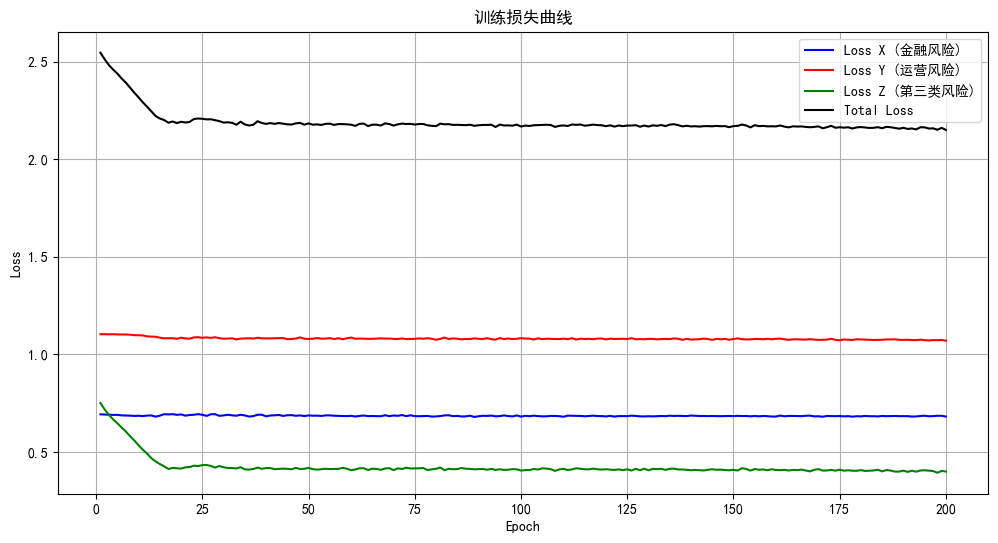

In [20]:
# 绘制损失曲线
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 设置字体为黑体
plt.rcParams["axes.unicode_minus"] = False  # 正常显示负号

plt.figure(figsize=(12, 6))
epochs = range(1, num_epochs + 1)
plt.plot(epochs, losses_x, 'b-', label='Loss X (金融风险)')
plt.plot(epochs, losses_y, 'r-', label='Loss Y (运营风险)')
plt.plot(epochs, losses_z, 'g-', label='Loss Z (第三类风险)')
plt.plot(epochs, total_losses, 'k-', label='Total Loss')
plt.title('训练损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 准备测试数据
X_test = df_test[feature_columns].values
y_x_test = df_test['target_x'].values
y_y_test = df_test['target_y'].values
y_z_test = df_test['target'].values

X_test_tensor = torch.FloatTensor(X_test)

# 模型评估
model.eval()
with torch.no_grad():
    pred_x, pred_y, pred_z = model(X_test_tensor)
    
    # 转换预测结果
    pred_x_binary = (pred_x.squeeze() > 0.5).float().numpy()  # 二分类
    pred_y_class = torch.argmax(pred_y, dim=1).numpy()        # 三分类
    pred_z_binary = (pred_z.squeeze() > 0.5).float().numpy()  # 二分类
    
    # 打印每个目标的类别分布
    print("数据分布情况：")
    print("\nTarget X (金融风险) 分布:")
    print("真实标签分布:", np.unique(y_x_test, return_counts=True))
    print("预测标签分布:", np.unique(pred_x_binary, return_counts=True))
    
    print("\nTarget Y (运营风险) 分布:")
    print("真实标签分布:", np.unique(y_y_test, return_counts=True))
    print("预测标签分布:", np.unique(pred_y_class, return_counts=True))
    
    print("\nTarget Z (第三类风险) 分布:")
    print("真实标签分布:", np.unique(y_z_test, return_counts=True))
    print("预测标签分布:", np.unique(pred_z_binary, return_counts=True))
    
    print("\n" + "="*50 + "\n")
    
    # 生成分类报告
    print("Target X (金融风险) 的分类报告：")
    print(classification_report(y_x_test, pred_x_binary, 
                              target_names=['0', '1'],
                              digits=2))
    
    
    
    
    
    # 生成混淆矩阵
    print("\n混淆矩阵：")
    print("\nTarget X (金融风险) 混淆矩阵：")
    cm_x = confusion_matrix(y_x_test, pred_x_binary)
    print(cm_x)
    
    
    
    
    
    # 计算每个类别的预测准确率
    print("\n各类别预测准确率：")
    
    print("\nTarget X (金融风险)：")
    for i in range(2):
        mask = (y_x_test == i)
        accuracy = np.mean(pred_x_binary[mask] == y_x_test[mask])
        print(f"类别 {i} 的准确率: {accuracy:.4f}")
    


数据分布情况：

Target X (金融风险) 分布:
真实标签分布: (array([0., 1.]), array([57, 50], dtype=int64))
预测标签分布: (array([1.], dtype=float32), array([107], dtype=int64))

Target Y (运营风险) 分布:
真实标签分布: (array([0., 1., 2.]), array([ 8, 43, 56], dtype=int64))
预测标签分布: (array([0], dtype=int64), array([107], dtype=int64))

Target Z (第三类风险) 分布:
真实标签分布: (array([0., 1.]), array([105,   2], dtype=int64))
预测标签分布: (array([0.], dtype=float32), array([107], dtype=int64))


Target X (金融风险) 的分类报告：
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        57
           1       0.47      1.00      0.64        50

    accuracy                           0.47       107
   macro avg       0.23      0.50      0.32       107
weighted avg       0.22      0.47      0.30       107


混淆矩阵：

Target X (金融风险) 混淆矩阵：
[[ 0 57]
 [ 0 50]]

各类别预测准确率：

Target X (金融风险)：
类别 0 的准确率: 0.0000
类别 1 的准确率: 1.0000


d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
print("\nTarget Y (运营风险) 的分类报告：")
print(classification_report(y_y_test, pred_y_class,
                              target_names=['0', '1', '2'],
                              digits=2))

print("\nTarget Y (运营风险) 混淆矩阵：")
cm_y = confusion_matrix(y_y_test, pred_y_class)
print(cm_y)

print("\nTarget Y (运营风险)：")
for i in range(3):
    mask = (y_y_test == i)
    accuracy = np.mean(pred_y_class[mask] == y_y_test[mask])
    print(f"类别 {i} 的准确率: {accuracy:.2f}")
    




Target Y (运营风险) 的分类报告：
              precision    recall  f1-score   support

           0       0.07      1.00      0.14         8
           1       0.00      0.00      0.00        43
           2       0.00      0.00      0.00        56

    accuracy                           0.07       107
   macro avg       0.02      0.33      0.05       107
weighted avg       0.01      0.07      0.01       107


Target Y (运营风险) 混淆矩阵：
[[ 8  0  0]
 [43  0  0]
 [56  0  0]]

Target Y (运营风险)：
类别 0 的准确率: 1.00
类别 1 的准确率: 0.00
类别 2 的准确率: 0.00


d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
print("\nTarget Z (第三类风险) 的分类报告：")
print(classification_report(y_z_test, pred_z_binary,
                              target_names=['0', '1'],
                              digits=2))
print("\nTarget Z (第三类风险) 混淆矩阵：")
cm_z = confusion_matrix(y_z_test, pred_z_binary)
print(cm_z)
print("\nTarget Z (第三类风险)：")
for i in range(2):
    mask = (y_z_test == i)
    accuracy = np.mean(pred_z_binary[mask] == y_z_test[mask])
    print(f"类别 {i} 的准确率: {accuracy:.2f}")


Target Z (第三类风险) 的分类报告：
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       105
           1       0.00      0.00      0.00         2

    accuracy                           0.98       107
   macro avg       0.49      0.50      0.50       107
weighted avg       0.96      0.98      0.97       107


Target Z (第三类风险) 混淆矩阵：
[[105   0]
 [  2   0]]

Target Z (第三类风险)：
类别 0 的准确率: 1.00
类别 1 的准确率: 0.00


d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [46]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 准备测试数据
X_test = df_test[feature_columns].values
y_x_test = df_test['target_x'].values
y_y_test = df_test['target_y'].values
y_z_test = df_test['target'].values

X_test_tensor = torch.FloatTensor(X_test)
y_x_test_tensor = torch.FloatTensor(y_x_test)
y_y_test_tensor = torch.LongTensor(y_y_test)
y_z_test_tensor = torch.FloatTensor(y_z_test)

# 模型评估
model.eval()
with torch.no_grad():
    pred_x, pred_y, pred_z = model(X_test_tensor)
    
    # 转换预测结果
    pred_x_binary = (pred_x.squeeze() > 0.5).float()  # 二分类
    pred_y_class = torch.argmax(pred_y, dim=1)        # 三分类
    pred_z_binary = (pred_z.squeeze() > 0.5).float()  # 二分类
    
    # 转换为numpy数组
    pred_x_np = pred_x_binary.numpy()
    pred_y_np = pred_y_class.numpy()
    pred_z_np = pred_z_binary.numpy()
    y_x_np = y_x_test_tensor.numpy()
    y_y_np = y_y_test_tensor.numpy()
    y_z_np = y_z_test_tensor.numpy()
    
    print("Target X (金融风险) 的分类报告：")
    print(classification_report(y_x_np, pred_x_np, target_names=['Class 0', 'Class 1']))
    print("\nTarget X的混淆矩阵：")
    print(confusion_matrix(y_x_np, pred_x_np))
    
    print("\n" + "="*50 + "\n")
    
    print("Target Y (运营风险) 的分类报告：")
    print(classification_report(y_y_np, pred_y_np, target_names=['Class 0', 'Class 1', 'Class 2']))
    print("\nTarget Y的混淆矩阵：")
    print(confusion_matrix(y_y_np, pred_y_np))
    
    print("\n" + "="*50 + "\n")
    
    print("Target Z (第三类风险) 的分类报告：")
    print(classification_report(y_z_np, pred_z_np, target_names=['Class 0', 'Class 1']))
    print("\nTarget Z的混淆矩阵：")
    print(confusion_matrix(y_z_np, pred_z_np))
    
    # 计算每个类别的具体预测数量
    print("\n预测结果统计：")
    print("Target X (金融风险):")
    print(f"实际 Class 0: {sum(y_x_np == 0)}, 预测 Class 0: {sum(pred_x_np == 0)}")
    print(f"实际 Class 1: {sum(y_x_np == 1)}, 预测 Class 1: {sum(pred_x_np == 1)}")
    
    print("\nTarget Y (运营风险):")
    print(f"实际 Class 0: {sum(y_y_np == 0)}, 预测 Class 0: {sum(pred_y_np == 0)}")
    print(f"实际 Class 1: {sum(y_y_np == 1)}, 预测 Class 1: {sum(pred_y_np == 1)}")
    print(f"实际 Class 2: {sum(y_y_np == 2)}, 预测 Class 2: {sum(pred_y_np == 2)}")
    
    print("\nTarget Z (第三类风险):")
    print(f"实际 Class 0: {sum(y_z_np == 0)}, 预测 Class 0: {sum(pred_z_np == 0)}")
    print(f"实际 Class 1: {sum(y_z_np == 1)}, 预测 Class 1: {sum(pred_z_np == 1)}")


Target X (金融风险) 的分类报告：
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00        57
     Class 1       0.47      1.00      0.64        50

    accuracy                           0.47       107
   macro avg       0.23      0.50      0.32       107
weighted avg       0.22      0.47      0.30       107


Target X的混淆矩阵：
[[ 0 57]
 [ 0 50]]


Target Y (运营风险) 的分类报告：
              precision    recall  f1-score   support

     Class 0       0.07      1.00      0.14         8
     Class 1       0.00      0.00      0.00        43
     Class 2       0.00      0.00      0.00        56

    accuracy                           0.07       107
   macro avg       0.02      0.33      0.05       107
weighted avg       0.01      0.07      0.01       107


Target Y的混淆矩阵：
[[ 8  0  0]
 [43  0  0]
 [56  0  0]]


Target Z (第三类风险) 的分类报告：
              precision    recall  f1-score   support

     Class 0       0.98      1.00      0.99       105
     Class 1       0.

d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Anaconda\lib\site-packages\sklearn\metrics\_classification.py:1565: Undefine

In [12]:
# 模型评估
model.eval()
with torch.no_grad():
    pred_x, pred_y = model(X_tensor)
    
    # 转换为二分类预测
    pred_x_binary = (pred_x.squeeze() > 0.5).float()
    pred_y_binary = (pred_y.squeeze() > 0.5).float()
    
    # 计算准确率
    accuracy_x = (pred_x_binary == y_x_tensor).float().mean()
    accuracy_y = (pred_y_binary == y_y_tensor).float().mean()
    
    print(f'Accuracy for target_x: {accuracy_x:.4f}')
    print(f'Accuracy for target_y: {accuracy_y:.4f}')


Accuracy for target_x: 0.5627
Accuracy for target_y: 0.7924
